#

In [ ]:
---
execute:
  eval: false
  echo: true
  warning: false
format:
  html:
    code-fold: false
---

Importing the packages.

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision.datasets import MNIST
from diffusers import DDPMScheduler, UNet2DModel

Plotting the noise schedule of DDPM.

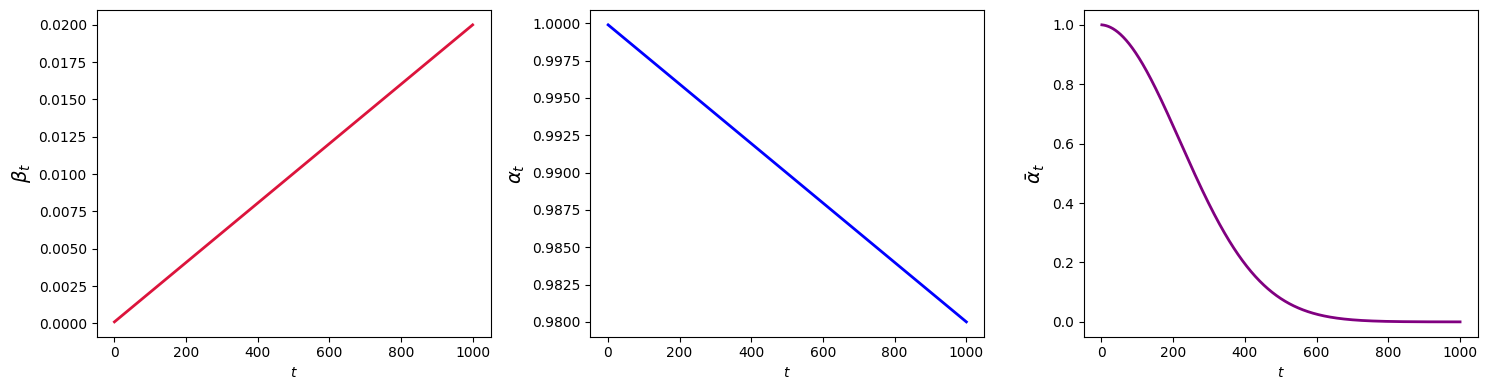

In [5]:
T = 1000
scheduler = DDPMScheduler(num_train_timesteps=T, beta_schedule="linear")

betas = scheduler.betas.numpy()
alphas = scheduler.alphas.numpy()
alphas_cumprod = scheduler.alphas_cumprod.numpy()

steps = np.arange(1, T + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(steps, betas, color="crimson", linewidth=2)
axes[0].set_ylabel(r"$\beta_t$", fontsize=14)
axes[0].set_xlabel(r"$t$")

axes[1].plot(steps, alphas, color="blue", linewidth=2)
axes[1].set_ylabel(r"$\alpha_t$", fontsize=14)
axes[1].set_xlabel(r"$t$")

axes[2].plot(steps, alphas_cumprod, color="purple", linewidth=2)
axes[2].set_ylabel(r"$\bar{\alpha}_t$", fontsize=14)
axes[2].set_xlabel(r"$t$")

plt.tight_layout()
plt.show()

Showing the diffusion process.

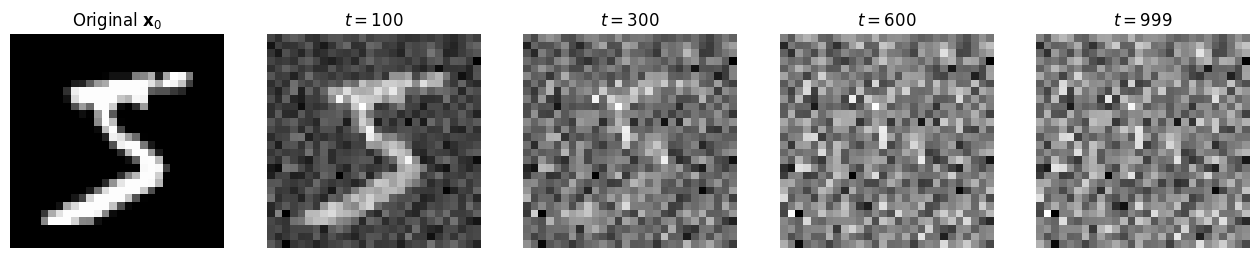

In [7]:
dataset = MNIST(root="./data", train=True, download=True, transform=transforms.ToTensor())
x0, _ = dataset[0]
x0 = x0.unsqueeze(0) * 2.0 - 1.0

selected_t = [0, 100, 300, 600, 999]
fig, axes = plt.subplots(1, len(selected_t), figsize=(16, 3))

epsilon = torch.randn_like(x0)

for i, t in enumerate(selected_t):
    if t == 0:
        xt = x0
        title = r"Original $\mathbf{x}_0$"
    else:
        t_tensor = torch.tensor([t], dtype=torch.long)
        xt = scheduler.add_noise(x0, epsilon, t_tensor)
        title = r"$t=$" + f"{t}"

    img = (xt.squeeze().numpy() + 1.0) / 2.0
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(title, fontsize=12)
    axes[i].axis("off")

plt.show()